In [18]:
# Load data

import pandas as pd
flights = pd.read_csv('flights.csv')
flights

,scheduled,actual,carrier,flight,tailnum,origin,dest,air_time,distance
0,"04/29/2023, 16:35","04/29/2023, 17:01",WN,1079,N230WN,ATL,HOU,110.0,696
1,"07/02/2023, 15:10","07/02/2023, 15:05",DL,355,N953AT,ATL,GPT,54.0,352
2,"12/25/2023, 10:55","12/25/2023, 10:53",WN,291,N413WN,ATL,RDU,57.0,356
3,"09/01/2023, 12:50","09/01/2023, 12:48",DL,1132,N947DZ,ATL,TYS,28.0,152
4,"12/14/2023, 07:05","12/14/2023, 07:02",DL,40,N332DN,ATL,BOS,121.0,946
...,...,...,...,...,...,...,...,...,...
4995,"11/15/2023, 14:20","11/15/2023, 14:17",WN,13,N400WN,ATL,MCO,63.0,404
4996,"04/09/2023, 19:50","04/09/2023, 19:58",OH,1320,N567NN,ATL,CLT,42.0,226
4997,"12/14/2023, 13:20","12/14/2023, 13:16",DL,695,N363NB,ATL,DAL,103.0,721
4998,"12/06/2023, 13:05","12/06/2023, 13:01",DL,911,N992AT,ATL,GSO,56.0,306


In [19]:
# Extract needed columns

departures = flights[['scheduled', 'actual']]
departures

,scheduled,actual
0,"04/29/2023, 16:35","04/29/2023, 17:01"
1,"07/02/2023, 15:10","07/02/2023, 15:05"
2,"12/25/2023, 10:55","12/25/2023, 10:53"
3,"09/01/2023, 12:50","09/01/2023, 12:48"
4,"12/14/2023, 07:05","12/14/2023, 07:02"
...,...,...
4995,"11/15/2023, 14:20","11/15/2023, 14:17"
4996,"04/09/2023, 19:50","04/09/2023, 19:58"
4997,"12/14/2023, 13:20","12/14/2023, 13:16"
4998,"12/06/2023, 13:05","12/06/2023, 13:01"


In [20]:
# Use info() method to check columns data types

departures.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   scheduled  5000 non-null   object
 1   actual     5000 non-null   object
dtypes: object(2)
memory usage: 78.3+ KB


In [21]:
# Convert strings to datetime using to_datetime() method

departures['scheduled'] = pd.to_datetime(departures['scheduled'])
departures['actual'] = pd.to_datetime(departures['actual'])
departures

C:\Users\IME\AppData\Local\Temp\ipykernel_8516\3243882754.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  departures['scheduled'] = pd.to_datetime(departures['scheduled'])
C:\Users\IME\AppData\Local\Temp\ipykernel_8516\3243882754.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  departures['actual'] = pd.to_datetime(departures['actual'])


,scheduled,actual
0,2023-04-29 16:35:00,2023-04-29 17:01:00
1,2023-07-02 15:10:00,2023-07-02 15:05:00
2,2023-12-25 10:55:00,2023-12-25 10:53:00
3,2023-09-01 12:50:00,2023-09-01 12:48:00
4,2023-12-14 07:05:00,2023-12-14 07:02:00
...,...,...
4995,2023-11-15 14:20:00,2023-11-15 14:17:00
4996,2023-04-09 19:50:00,2023-04-09 19:58:00
4997,2023-12-14 13:20:00,2023-12-14 13:16:00
4998,2023-12-06 13:05:00,2023-12-06 13:01:00


In [22]:
# Confirm data type change

departures.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   scheduled  5000 non-null   datetime64[ns]
 1   actual     5000 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 78.3 KB


In [23]:
# Calculate flight delays

departures['delay'] = departures.eval('actual - scheduled')
departures

C:\Users\IME\AppData\Local\Temp\ipykernel_8516\837680766.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  departures['delay'] = departures.eval('actual - scheduled')


,scheduled,actual,delay
0,2023-04-29 16:35:00,2023-04-29 17:01:00,0 days 00:26:00
1,2023-07-02 15:10:00,2023-07-02 15:05:00,-1 days +23:55:00
2,2023-12-25 10:55:00,2023-12-25 10:53:00,-1 days +23:58:00
3,2023-09-01 12:50:00,2023-09-01 12:48:00,-1 days +23:58:00
4,2023-12-14 07:05:00,2023-12-14 07:02:00,-1 days +23:57:00
...,...,...,...
4995,2023-11-15 14:20:00,2023-11-15 14:17:00,-1 days +23:57:00
4996,2023-04-09 19:50:00,2023-04-09 19:58:00,0 days 00:08:00
4997,2023-12-14 13:20:00,2023-12-14 13:16:00,-1 days +23:56:00
4998,2023-12-06 13:05:00,2023-12-06 13:01:00,-1 days +23:56:00


In [24]:
# Flag late flight by 900 second (15 minute) late using dt.total_seconds()

departures['is_late'] = departures['delay'].dt.total_seconds() > 900
departures

C:\Users\IME\AppData\Local\Temp\ipykernel_8516\1116788553.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  departures['is_late'] = departures['delay'].dt.total_seconds() > 900


,scheduled,actual,delay,is_late
0,2023-04-29 16:35:00,2023-04-29 17:01:00,0 days 00:26:00,True
1,2023-07-02 15:10:00,2023-07-02 15:05:00,-1 days +23:55:00,False
2,2023-12-25 10:55:00,2023-12-25 10:53:00,-1 days +23:58:00,False
3,2023-09-01 12:50:00,2023-09-01 12:48:00,-1 days +23:58:00,False
4,2023-12-14 07:05:00,2023-12-14 07:02:00,-1 days +23:57:00,False
...,...,...,...,...
4995,2023-11-15 14:20:00,2023-11-15 14:17:00,-1 days +23:57:00,False
4996,2023-04-09 19:50:00,2023-04-09 19:58:00,0 days 00:08:00,False
4997,2023-12-14 13:20:00,2023-12-14 13:16:00,-1 days +23:56:00,False
4998,2023-12-06 13:05:00,2023-12-06 13:01:00,-1 days +23:56:00,False


In [25]:
# Use dt.strftime() to get day of the week for each flights

departures['day_name'] = departures['actual'].dt.strftime('%a')
departures

C:\Users\IME\AppData\Local\Temp\ipykernel_8516\290562311.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  departures['day_name'] = departures['actual'].dt.strftime('%a')


,scheduled,actual,delay,is_late,day_name
0,2023-04-29 16:35:00,2023-04-29 17:01:00,0 days 00:26:00,True,Sat
1,2023-07-02 15:10:00,2023-07-02 15:05:00,-1 days +23:55:00,False,Sun
2,2023-12-25 10:55:00,2023-12-25 10:53:00,-1 days +23:58:00,False,Mon
3,2023-09-01 12:50:00,2023-09-01 12:48:00,-1 days +23:58:00,False,Fri
4,2023-12-14 07:05:00,2023-12-14 07:02:00,-1 days +23:57:00,False,Thu
...,...,...,...,...,...
4995,2023-11-15 14:20:00,2023-11-15 14:17:00,-1 days +23:57:00,False,Wed
4996,2023-04-09 19:50:00,2023-04-09 19:58:00,0 days 00:08:00,False,Sun
4997,2023-12-14 13:20:00,2023-12-14 13:16:00,-1 days +23:56:00,False,Thu
4998,2023-12-06 13:05:00,2023-12-06 13:01:00,-1 days +23:56:00,False,Wed


In [26]:
# Percentage of flights delayed by day of week

proportion_delayed = departures.groupby('day_name')['is_late'].mean()
percent_delayed = proportion_delayed * 100
percent_delayed

day_name
Fri    22.593583
Mon    20.185923
Sat    18.558282
Sun    23.376623
Thu    20.939597
Tue    15.419847
Wed    16.691285
Name: is_late, dtype: float64

In [27]:
# Use reindex() to reorder percent_delayed in natural day of week

new_index_order = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
percent_delayed = percent_delayed.reindex(new_index_order)
percent_delayed

day_name
Sun    23.376623
Mon    20.185923
Tue    15.419847
Wed    16.691285
Thu    20.939597
Fri    22.593583
Sat    18.558282
Name: is_late, dtype: float64

Text(0, 0.5, 'Percent Delayed')

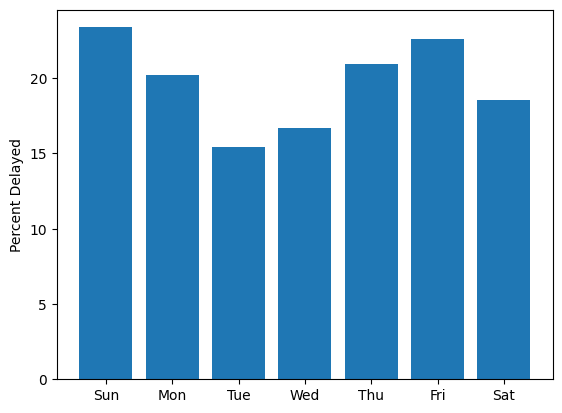

In [28]:
# Plot the data

import matplotlib.pyplot as plt

plt.bar(percent_delayed.index, percent_delayed)
plt.ylabel('Percent Delayed')